# <font size="6" color="blue"><b># Class Practice 10: 模組與套件</font></b>  
This version is updated on 2026/5/28  
練習準備：請先確保已讀入Housing.csv 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 讀取原始資料
df = pd.read_csv('Housing.csv')

# 解決 Matplotlib 中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 練習1：特定條件房屋篩選（單一條件）
請編寫程式碼，從 df 中篩選出房間數（bedrooms）剛好等於 4 間的所有房屋，並使用 .head() 顯示前 5 筆資料。  
提示：使用比較運算子 ==。  

In [4]:
result1 = df[df['bedrooms'] == 4]
result1.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished


# 練習2：多條件複合篩選與特定欄位選取
請找出有冷氣（airconditioning 為 'yes'）且有地下室（basement 為 'yes'）的房屋。  
篩選出來後，請只抽取出 price、area、airconditioning、basement 這四個欄位組成新的子表格，並印出該子表格的前 5 筆資料。  
提示：多條件記得用 () 包裹並用 & 連結；選取多欄位要用雙重中括號 [[...]]。  

In [5]:
result2 = df[(df['airconditioning'] == 'yes') & (df['basement'] == 'yes')][['price', 'area', 'airconditioning', 'basement']]
result2.head()

,price,area,airconditioning,basement
3,12215000,7500,yes,yes
4,11410000,7420,yes,yes
5,10850000,7500,yes,yes
8,9870000,8100,yes,yes
10,9800000,13200,yes,yes


# 練習3：資料排序與無索引存檔
請將原始資料中房價（price）由貴到便宜（遞減排序）進行排序。  
排序完成後，將前 50 筆房價最貴的房屋資料，存檔為新檔案 top_50_expensive.csv，且不可將流水號索引（Index）存入。    
提示：由大到小排序請設定 ascending=False；取前 50 筆可使用 .head(50)。  

In [6]:
df_sorted = df.sort_values(by='price',ascending=False)

df_top50 = df_sorted.head(50)

df_top50.to_csv('top_50_expensive.csv',index=False)

# 練習4：NumPy 陣列統計與計算
請利用 .to_numpy() 將房屋的面積（area）欄位轉換為 NumPy 陣列。  
接著使用 NumPy 的統計函式計算並印出該陣列的平均面積（Mean）與最大面積（Max）。  
提示：使用 np.mean() 與 np.max()。

In [10]:
area_array = df['area'].to_numpy()

max_area = np.max(area_array)
mean_area = np.mean(area_array)

print(f"房價平均數：{mean_area:,.2f}")
print(f"最高房價：{max_area:,}")


房價平均數：5,150.54
最高房價：16,200


# 練習5：進階思考題：使用 NumPy 遮罩篩選
承接題目 4 的 area_array。請使用 NumPy 的布林遮罩（Mask）機制，找出所有面積大於 10,000 平方英尺的房屋數量，並將結果印出來。  
提示：先建立 mask = area_array > 10000，再使用 np.sum(mask) 算出 True 的總個數。  

In [ ]:
mask = area_array > 10000

count = np.sum(mask)
print(f"面積大於 10,000 平方英尺的房屋數量：{count}")

面積大於 10000 平方英尺的房屋數量：18


# 練習6：離群值（極端值）偵測與 Z-Score 分佈視覺化
統計學中，我們常使用 Z-Score（標準分數）來判斷一筆數據是否為離群值。公式為：
$$Z = \frac{X - \mu}{\sigma}$$
其中 $X$ 為原始數據，$\mu$ 為平均值，$\sigma$ 為標準差）。
通常當 $|Z| > 2$ 時，我們會認為該房屋的面積在市場中屬於「極端大」或「極端小」的特殊案例。  
【題目描述】  
* 請利用 Pandas 抽出房屋的「面積（area）」欄位，並將其轉換成 NumPy 陣列。
* 使用 NumPy 的統計函式算出該陣列的平均值與標準差，並利用 NumPy 的廣播機制（矩陣直接加減乘除）計算出每個房屋面積的 Z-Score 陣列。
* 利用 NumPy 的條件遮罩（Mask），找出 $Z > 2$ （即面積比平均大上兩個標準差以上）的極端大房屋，並印出總共有幾筆。
* 使用 Matplotlib 繪製一張「Z-Score 分佈直方圖（Histogram）」，並利用 plt.axvline() 畫一條位於 $Z = 2$ 的紅色虛線作為標記。

極端大房屋數量：24 筆


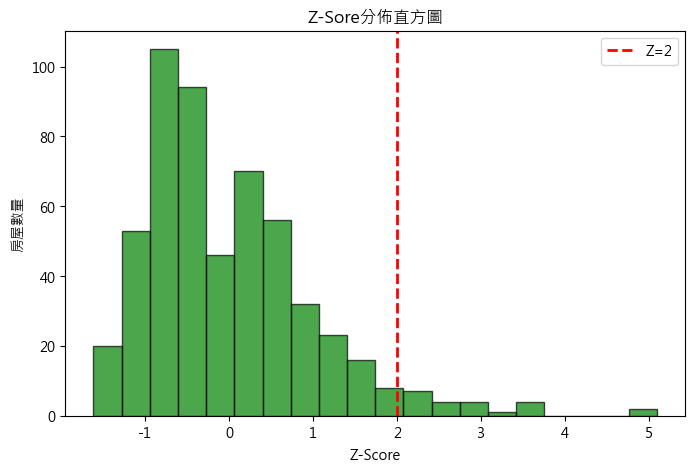

In [32]:
area_array = df['area'].to_numpy()

mean_area = np.mean(area_array)
std_area = np.std(area_array)
z_score = (area_array-mean_area) / std_area

mask = z_score > 2
count_mask = np.sum(mask)
print(f"極端大房屋數量：{count_mask} 筆")

plt.figure(figsize=(8,5))
plt.hist(z_score, bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Z-Sore分佈直方圖')
plt.xlabel('Z-Score')
plt.ylabel('房屋數量')
plt.axvline(x=2,color='red',linestyle='--',linewidth='2',label='Z=2')
plt.legend()
plt.show()


# 練習7: 多類別矩陣運算與多子圖（Subplots）對比呈現 
* 我們想知道「有冷氣」與「沒冷氣」的房子，在每平方英尺的單位售價上是否有顯著差異。  
* 另外，我們希望能把這兩種房子的數據，用「兩張並排的圖表」呈現在同一個畫布上，方便向主管報告。    　
* 請用 Pandas 將資料集拆分成兩個子 DataFrame：  
ac_yes（所有 airconditioning == 'yes' 的房屋）  
ac_no（所有 airconditioning == 'no' 的房屋）  
* 將這兩組的 price 與 area 欄位分別轉成 NumPy 陣列：
算出有冷氣房的單位地價陣列：unit_price_yes = 房價陣列 / 面積陣列  
算出沒冷氣房的單位地價陣列：unit_price_no = 房價陣列 / 面積陣列  
* 使用 NumPy 算出這兩組的「單位地價中位數」（np.median），並在螢幕上印出做對比。
* 使用 Matplotlib 的 plt.subplots(1, 2) 建立一個 1 列 2 行（左右並排）的畫布。  
左邊的子圖 (ax1)：畫出「有冷氣房屋」的面積 vs. 房價的藍色散佈圖。  
右邊的子圖 (ax2)：畫出「沒冷氣房屋」的面積 vs. 房價的橘色散佈圖。  

【單位地價中位數對比】
有冷氣房屋: 1065.39 元/平方英尺
沒冷氣房屋: 913.04 元/平方英尺


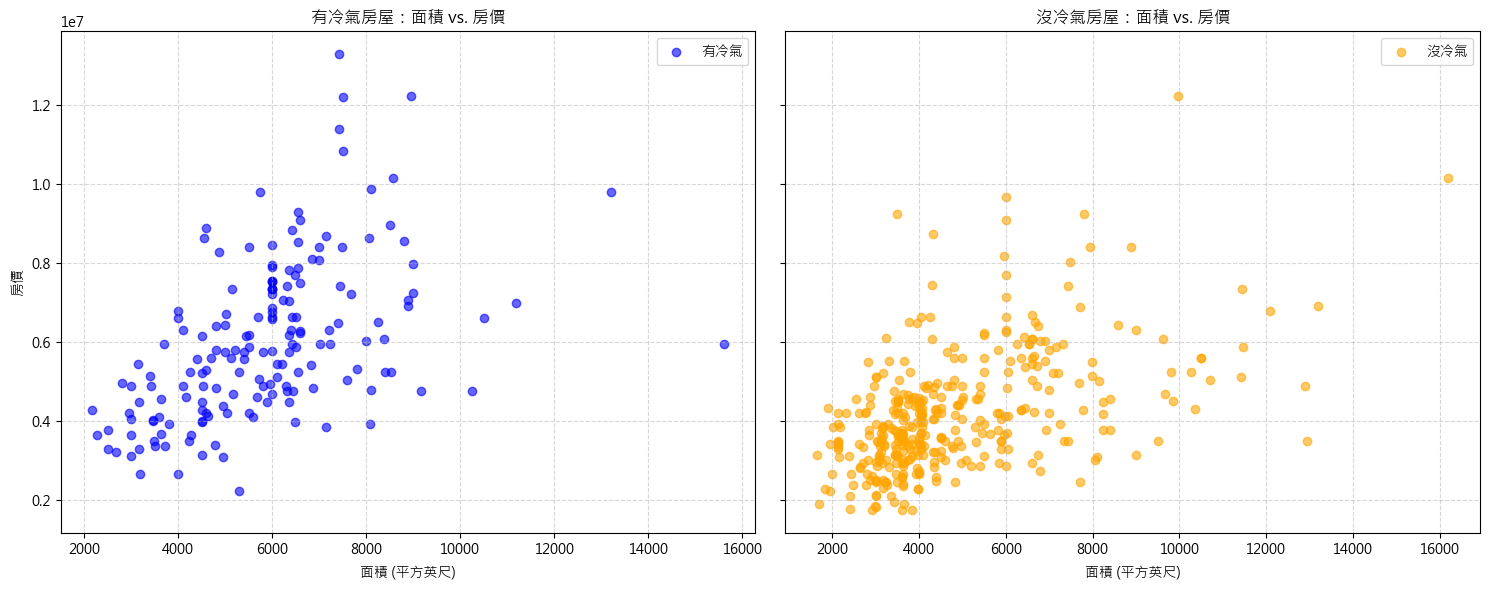

In [34]:
ac_yes = df[df['airconditioning'] == 'yes']
ac_no = df[df['airconditioning'] == 'no']

unit_price_yes = ac_yes['price'].to_numpy() / ac_yes['area'].to_numpy()
unit_price_no = ac_no['price'].to_numpy() / ac_no['area'].to_numpy()

median_yes = np.median(unit_price_yes)
median_no = np.median(unit_price_no)
print(f"【單位地價中位數對比】")
print(f"有冷氣房屋: {median_yes:.2f} 元/平方英尺")
print(f"沒冷氣房屋: {median_no:.2f} 元/平方英尺")


fig,(ax1,ax2) = plt.subplots(1,2,figsize=(15,6),sharey=True)


ax1.scatter(ac_yes['area'], ac_yes['price'], color='blue', alpha=0.6, label='有冷氣')
ax1.set_title('有冷氣房屋：面積 vs. 房價')
ax1.set_xlabel('面積 (平方英尺)')
ax1.set_ylabel('房價')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)


ax2.scatter(ac_no['area'], ac_no['price'], color='orange', alpha=0.6, label='沒冷氣')
ax2.set_title('沒冷氣房屋：面積 vs. 房價')
ax2.set_xlabel('面積 (平方英尺)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()